In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import torch

ModuleNotFoundError: No module named 'sklearn'

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, Lasso, ElasticNet


In [3]:
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
set_seed(42)

In [4]:
import numpy as np

def load_glove_embeddings(glove_file):
    embeddings = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove_embeddings = load_glove_embeddings('glove.6B/glove.6B.50d.txt')


In [125]:
(glove_embeddings['today'] + glove_embeddings['is'] + glove_embeddings['good']) / 3

np.float32(0.26702628)

In [ ]:
50
50
50

In [126]:
text = "today is good" 
words = text.split()
word_vectors = []
for word in words:
    if word in glove_embeddings:
        word_vectors.append(glove_embeddings[word])

In [5]:
def get_glove_embedding(text):
    if not isinstance(text, str):
        #print(f"hello: =={type(text)}: {text}===")
        emb = np.zeros(50)
    else:
        words = text.split()
        word_vectors = []
        for word in words:
            if word in glove_embeddings:
                word_vectors.append(glove_embeddings[word])
        emb = np.mean(word_vectors, axis=0) if word_vectors else np.zeros(50)  # Default to 50-dimensional zero vector
    return emb.tolist()

In [138]:
text_data = [
    "Today is good.",
    "It is a bad day today.",
    "I like today.",
    "Today is a good day.",
]

# Convert each text into an embedding vector (mean of word embeddings)
text_vectors = np.array([get_glove_embedding(text) for text in text_data])

print(text_vectors.shape)  # Each row is a vector representation of the corresponding text

(4, 50)


In [142]:
from sentence_transformers import SentenceTransformer

#bert_model = SentenceTransformer("all-MiniLM-L6-v2")
bert_model = SentenceTransformer('paraphrase-distilroberta-base-v1')

sentences = [
    "Today is good.",
    "It's a bad day today.",
    "I like today.",
    "Today is a good day.",
]

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
bert_model.to(device) 
bert_model.eval()

SentenceTransformer(
  (0): Transformer({'max_seq_length': 128, 'do_lower_case': False}) with Transformer model: RobertaModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

In [143]:
embeddings = bert_model.encode(sentences)
print(embeddings.shape)

(4, 768)


In [49]:
embeddings

array([[ 0.47178483,  0.6052658 ,  0.06659266, ..., -0.19827993,
         0.11707324,  0.27150214],
       [ 0.18285733,  0.37455872,  0.02753438, ..., -0.03056103,
        -0.02543047,  0.08550906],
       [ 0.31016716,  0.5968426 , -0.0037415 , ..., -0.019596  ,
         0.14586078,  0.00929278],
       [ 0.30015174,  0.39726728,  0.08002092, ..., -0.20511909,
         0.05775461,  0.24086848]], dtype=float32)

# read data

In [19]:
input_df = pd.read_csv('train.csv')
train_df, valid_df = train_test_split(input_df, test_size=0.2, random_state=42)

test_df = pd.read_csv('test.csv')

/var/folders/lk/h5__mp8n6t1___j5kc3kqf0m0000gn/T/ipykernel_96041/572932260.py:1: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  input_df = pd.read_csv('train.csv')
/var/folders/lk/h5__mp8n6t1___j5kc3kqf0m0000gn/T/ipykernel_96041/572932260.py:4: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('test.csv')


In [38]:
# numerical features
int_feature_names = ['accommodates', 'bedrooms', 'beds', 'guests_included', 'minimum_nights', \
                     'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count']
float_feature_names = ['bathrooms', 'reviews_per_month']

text_feature_names = ['description']

In [54]:
GLOVE_EMB_DIM = 50
BERT_EMB_DIM = 768

def encoder_text(df, use_glove, txt_batch_size):
    if use_glove:
        for feature in text_feature_names:
            df[feature + '_emb'] = df[feature].apply(lambda x: get_glove_embedding(x))
    else:
        for feature in text_feature_names:
            df[feature] = df[feature].fillna('').apply(lambda x: x if isinstance(x, str) else '')
            embeddings = bert_model.encode(df[feature].tolist(), batch_size=txt_batch_size,
                                           device=device, show_progress_bar=True).tolist()
            df[feature + '_emb'] = embeddings


In [144]:
abc = valid_df[:10].copy()
encoder_text(abc, use_glove, txt_batch_size)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [145]:
abc[['description', 'description_emb']]

,description,description_emb
20633,"Hi All, This is my first time on AirBnB (so be...","[-0.1436566710472107, -0.0761282667517662, 0.0..."
16048,Must be cat friendly! You will be sharing the ...,"[-0.055780667811632156, 0.212946355342865, 0.0..."
10804,"Quiet, cozy 1-bedroom apartment with a full-si...","[-0.2029169201850891, 0.07569951564073563, 0.1..."
2505,"Beautiful apartment in sunny flat, in Williams...","[0.08516095578670502, 0.3591535985469818, 0.04..."
1796,Hi! This apartment is walking distance from Ce...,"[0.08204537630081177, 0.18288786709308624, 0.1..."
6870,Midtown East private room; Nice neighborhood -...,"[-0.12302190810441971, 0.36216336488723755, -0..."
16041,Our apartment is located in one of the best pa...,"[-0.10457581281661987, 0.54050612449646, 0.017..."
6481,"Recently renovated, three-story brownstone tow...","[-0.11880265176296234, 0.057048872113227844, 0..."
20730,The apartment is spacious and airy. Always som...,"[-0.084322988986969, 0.1465643048286438, 0.354..."
5859,A cozy guest-room inside my modern 2-bedroom a...,"[-0.20143406093120575, 0.25999218225479126, 0...."


In [61]:
use_glove = False
txt_batch_size = 32

encoder_text(valid_df, use_glove, txt_batch_size)

Batches:   0%|          | 0/210 [00:00<?, ?it/s]

In [62]:
encoder_text(test_df, use_glove, txt_batch_size)

Batches:   0%|          | 0/542 [00:00<?, ?it/s]

In [63]:
encoder_text(train_df, use_glove, txt_batch_size)

Batches:   0%|          | 0/839 [00:00<?, ?it/s]

In [64]:
# train_df.drop(train_df[train_df['price'] < 9.0].index, inplace=True)
# train_df.reset_index(drop=True, inplace=True)

# input_df['bedrooms'] = np.where(input_df['bedrooms'] > 5, 5, input_df['bedrooms'])
# input_df['bedrooms'] = np.where(input_df['bedrooms'] < 1, 1, input_df['bedrooms'])
# input_df['beds'] = np.where(input_df['beds'] > 8, 8, input_df['beds'])
# input_df['beds'] = np.where(input_df['beds'] < 1, 1, input_df['beds'])
# input_df['guests_included'] = np.where(input_df['guests_included'] > 10, 10, input_df['guests_included'])
# input_df['bathrooms'] = np.where(input_df['bathrooms'] > 5, 5, input_df['bathrooms'])

# #train_df['log_price'] = np.log(0.1 + train_df['price'])
# train_df['log_price'] = np.log1p(train_df['price'])

use_log_price = False

if use_log_price:
    y_col = 'log_price'
else:
    y_col = 'price'

In [65]:
len(train_df), len(valid_df), len(test_df)

(26830, 6708, 17337)

# preprocess data

In [66]:

numerical_feature_names = int_feature_names + float_feature_names
train_means = train_df[numerical_feature_names].mean()
train_df[numerical_feature_names] = train_df[numerical_feature_names].fillna(train_means)
valid_df[numerical_feature_names] = valid_df[numerical_feature_names].fillna(train_means)
test_df[numerical_feature_names] = test_df[numerical_feature_names].fillna(train_means)

#normerilize
scaler = StandardScaler()
scaler.fit(train_df[numerical_feature_names])
train_df[numerical_feature_names] = scaler.transform(train_df[numerical_feature_names])
valid_df[numerical_feature_names] = scaler.transform(valid_df[numerical_feature_names])
test_df[numerical_feature_names] = scaler.transform(test_df[numerical_feature_names])

# categorical features
train_df['zipcode'] = pd.to_numeric(train_df['zipcode'], errors='coerce').fillna(0).astype(int).astype('str')
valid_df['zipcode'] = pd.to_numeric(valid_df['zipcode'], errors='coerce').fillna(0).astype(int).astype('str')
test_df['zipcode'] = pd.to_numeric(test_df['zipcode'], errors='coerce').fillna(0).astype(int).astype('str')

categorical_feature_names = ['zipcode', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'instant_bookable', 'cancellation_policy']

categories = []

for feature in categorical_feature_names:
    categories.append([x for x in list(set(train_df[feature])) if type(x) is str])



In [69]:
def create_feature(row):
    int_features = []
    for int_feature_name in int_feature_names:
        int_features.append(row[int_feature_name])
    float_features = []
    for float_feature_name in float_feature_names:
        float_features.append(row[float_feature_name])

    one_hot_features = []
    for i, col in enumerate(categorical_feature_names):
        one_hot = [int(row[col] == category) for category in categories[i]]
        one_hot_features.extend(one_hot)
    
    text_features = []
    for feature in text_feature_names:
        text_features.extend(row[feature + '_emb'])
    
    return int_features + float_features + one_hot_features + text_features


In [71]:
train_X, train_y = [], []
for (idx, row) in train_df.iterrows():
    price = float(row[y_col])
    feature = create_feature(row)

    train_X.append(feature)
    train_y.append(price)

In [72]:
valid_ids, valid_X, valid_y = [], [], []
for (idx, row) in valid_df.iterrows():
    price = float(row['price'])
    valid_ids.append(row.id)
    feature = create_feature(row)

    valid_X.append(feature)
    valid_y.append(price)

# train model

In [74]:
len(train_X[0])

1010

In [75]:
mlp = MLPRegressor(hidden_layer_sizes=(500, 100, 30, 10), 
                     batch_size=32,
                     learning_rate_init=2e-5,
                     max_iter=200, # epoch
                     random_state=42,
                     early_stopping=True,
                    )
mlp.fit(train_X, train_y)


MLPRegressor(batch_size=32, early_stopping=True,
             hidden_layer_sizes=(500, 100, 30, 10), learning_rate_init=2e-05,
             random_state=42)

In [76]:
# 78, 89

if use_log_price:
    train_y_pred = mlp.predict(train_X)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_y_pred = mlp.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    train_y_pred = mlp.predict(train_X)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_y_pred = mlp.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 75.1145
 88.8268


In [117]:
len(mlp.loss_curve_)

99

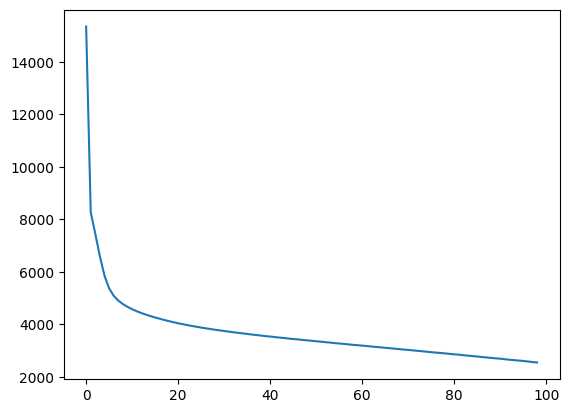

In [116]:
plt.plot(mlp.loss_curve_)


In [102]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=200, max_depth=10, objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=10,
    learning_rate=0.05,  
    reg_alpha=1,
    reg_lambda=0.1,
    min_child_weight=5, min_split_loss=5,
    random_state=42, subsample=0.8, colsample_bytree=0.8)

xgb_model.fit(train_X[:-1000], train_y[:-1000], 
              eval_set=[(train_X[-1000:], train_y[-1000:])] 
              )

[0]	validation_0-rmse:117.30726
[1]	validation_0-rmse:114.30657
[2]	validation_0-rmse:112.14611
[3]	validation_0-rmse:109.88604
[4]	validation_0-rmse:108.02529
[5]	validation_0-rmse:105.97206
[6]	validation_0-rmse:104.15893
[7]	validation_0-rmse:102.27458
[8]	validation_0-rmse:100.71425
[9]	validation_0-rmse:99.09828
[10]	validation_0-rmse:97.53920
[11]	validation_0-rmse:96.31945
[12]	validation_0-rmse:95.38928
[13]	validation_0-rmse:94.32754
[14]	validation_0-rmse:93.37081
[15]	validation_0-rmse:92.35433
[16]	validation_0-rmse:91.30008
[17]	validation_0-rmse:90.53771
[18]	validation_0-rmse:89.94254
[19]	validation_0-rmse:89.30235
[20]	validation_0-rmse:88.69325
[21]	validation_0-rmse:88.19322
[22]	validation_0-rmse:87.58379
[23]	validation_0-rmse:87.08303
[24]	validation_0-rmse:86.74041
[25]	validation_0-rmse:86.41943
[26]	validation_0-rmse:86.14385
[27]	validation_0-rmse:85.95094
[28]	validation_0-rmse:85.72991
[29]	validation_0-rmse:85.45118
[30]	validation_0-rmse:85.27878
[31]	vali

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=5, min_split_loss=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [103]:
if use_log_price:
    train_y_pred = xgb_model.predict(train_X)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_y_pred = xgb_model.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    train_y_pred = xgb_model.predict(train_X)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_y_pred = xgb_model.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 37.2883
 89.8699


In [118]:
import xgboost as xgb

xgb_model2 = xgb.XGBRegressor(
    n_estimators=200, max_depth=10, objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=10,
    learning_rate=0.05,  
    reg_lambda=0.5,
    min_child_weight=8, min_split_loss=5,
    random_state=10, subsample=0.8, colsample_bytree=0.8)

xgb_model2.fit(train_X[:-1000], train_y[:-1000], 
              eval_set=[(train_X[-1000:], train_y[-1000:])] 
              )

[0]	validation_0-rmse:117.53599
[1]	validation_0-rmse:114.93805
[2]	validation_0-rmse:112.87682
[3]	validation_0-rmse:110.25683
[4]	validation_0-rmse:107.84584
[5]	validation_0-rmse:106.18761
[6]	validation_0-rmse:104.38469
[7]	validation_0-rmse:102.70232
[8]	validation_0-rmse:101.17277
[9]	validation_0-rmse:99.81160
[10]	validation_0-rmse:98.52891
[11]	validation_0-rmse:97.32495
[12]	validation_0-rmse:96.11736
[13]	validation_0-rmse:95.29145
[14]	validation_0-rmse:94.31881
[15]	validation_0-rmse:93.32676
[16]	validation_0-rmse:92.50952
[17]	validation_0-rmse:91.73432
[18]	validation_0-rmse:91.05260
[19]	validation_0-rmse:90.46547
[20]	validation_0-rmse:89.81825
[21]	validation_0-rmse:89.06930
[22]	validation_0-rmse:88.61884
[23]	validation_0-rmse:88.36218
[24]	validation_0-rmse:87.87836
[25]	validation_0-rmse:87.44091
[26]	validation_0-rmse:87.04745
[27]	validation_0-rmse:86.58100
[28]	validation_0-rmse:86.30153
[29]	validation_0-rmse:85.88332
[30]	validation_0-rmse:85.57542
[31]	vali

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=8, min_split_loss=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [119]:
if use_log_price:
    train_y_pred = xgb_model2.predict(train_X)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_y_pred = xgb_model2.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    train_y_pred = xgb_model2.predict(train_X)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_y_pred = xgb_model2.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 45.2023
 89.5066


In [107]:
gradient_boosting = GradientBoostingRegressor(
    verbose=1,
    learning_rate=0.05, max_features='sqrt', subsample=0.8,
    n_estimators=150, max_depth=5, 
    min_samples_split=8, min_samples_leaf=5,random_state=42)
gradient_boosting.fit(train_X, train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1       17200.9719         429.5050           52.04s
         2       16526.8733       -1107.2950           51.48s
         3       16620.5292        1523.7924           50.17s
         4       16028.1079        -451.4520           49.45s
         5       15934.8717        1173.5463           49.10s
         6       15662.0610         365.4004           48.43s
         7       15427.0900          35.6924           48.10s
         8       15111.6546        -234.5342           47.79s
         9       15092.4932         877.5102           47.39s
        10       15137.3324        1982.2492           47.09s
        20       11963.8627       -3496.9305           43.47s
        30       10583.7584       -1837.0561           40.10s
        40       10221.9959         170.0822           36.99s
        50        9178.3745        -826.6862           34.70s
        60        8624.4821         342.3045           31.27s
       

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, max_features='sqrt',
                          min_samples_leaf=5, min_samples_split=8,
                          n_estimators=150, random_state=42, subsample=0.8,
                          verbose=1)

In [108]:
if use_log_price:
    train_y_pred = gradient_boosting.predict(train_X)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_y_pred = gradient_boosting.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    train_y_pred = gradient_boosting.predict(train_X)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_y_pred = gradient_boosting.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 78.1694
 95.5980


In [42]:
if use_log_price:
    train_y_pred = gradient_boosting.predict(train_X)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_y_pred = gradient_boosting.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    train_y_pred = gradient_boosting.predict(train_X)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_y_pred = gradient_boosting.predict(valid_X)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 77.2604
 89.4176


In [146]:
# submitted 82.26326
models = [mlp, xgb_model, xgb_model2]#gradient_boosting]

if use_log_price:
    preds = np.array([model.predict(train_X) for model in models])
    train_y_pred = np.mean(preds, axis=0)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_preds = np.array([model.predict(valid_X) for model in models])
    valid_y_pred = np.mean(valid_preds, axis=0)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    preds = np.array([model.predict(train_X) for model in models])
    train_y_pred = np.mean(preds, axis=0)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_preds = np.array([model.predict(valid_X) for model in models])
    valid_y_pred = np.mean(valid_preds, axis=0)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 49.5828
 86.7343


In [110]:
# submitted 82.26326
models = [mlp, xgb_model]#gradient_boosting]

if use_log_price:
    preds = np.array([model.predict(train_X) for model in models])
    train_y_pred = np.mean(preds, axis=0)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_preds = np.array([model.predict(valid_X) for model in models])
    valid_y_pred = np.mean(valid_preds, axis=0)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    preds = np.array([model.predict(train_X) for model in models])
    train_y_pred = np.mean(preds, axis=0)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_preds = np.array([model.predict(valid_X) for model in models])
    valid_y_pred = np.mean(valid_preds, axis=0)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 53.1885
 86.6387


In [47]:
models = [mlp, gradient_boosting, forest]

if use_log_price:
    preds = np.array([model.predict(train_X) for model in models])
    train_y_pred = np.mean(preds, axis=0)
    print(f"{root_mean_squared_error(np.exp(train_y), np.exp(train_y_pred)): .4f}")

    valid_preds = np.array([model.predict(valid_X) for model in models])
    valid_y_pred = np.mean(valid_preds, axis=0)
    print(f"{root_mean_squared_error(valid_y, np.exp(valid_y_pred)): .4f}")
else:
    preds = np.array([model.predict(train_X) for model in models])
    train_y_pred = np.mean(preds, axis=0)
    print(f"{root_mean_squared_error(train_y, train_y_pred): .4f}")

    valid_preds = np.array([model.predict(valid_X) for model in models])
    valid_y_pred = np.mean(valid_preds, axis=0)
    print(f"{root_mean_squared_error(valid_y, valid_y_pred): .4f}")

 76.3108
 88.0995


In [153]:
result = valid_df.copy()
result['predicted'] = valid_y_pred
result['pred_true_diff'] = valid_y - valid_y_pred
cols = numerical_feature_names + categorical_feature_names \
        + text_feature_names + ['price', 'predicted', 'pred_true_diff']
result[cols].to_csv('valid.csv', index = False)

In [111]:

test_ids, test_X = [], []
for (idx, row) in test_df.iterrows():
    feature = create_feature(row)
    test_ids.append(row.id)
    test_X.append(feature)

if use_log_price:
    preds = np.array([model.predict(test_X) for model in models])
    test_y = np.exp(np.mean(preds, axis=0))
else:
    preds = np.array([model.predict(test_X) for model in models])
    test_y = np.mean(preds, axis=0)


In [112]:
output_df = pd.DataFrame()
output_df['Id'] = test_ids
output_df['Predicted'] = test_y
output_df.to_csv('solution.csv', index = False)

In [182]:
prediction_results = np.array([model.predict(train_X) for model in models]).T

In [195]:
from sklearn.linear_model import ElasticNet
final_model = ElasticNet(alpha=700, l1_ratio=0.9) 
final_model.fit(prediction_results, train_y)


ElasticNet(alpha=700, l1_ratio=0.9)

In [196]:
final_preds = final_model.predict(prediction_results)
print(f"{root_mean_squared_error(train_y, final_preds): .4f}")

valid_prediction_results = np.array([model.predict(valid_X) for model in models]).reshape(len(valid_X), -1)
valid_final_preds = final_model.predict(valid_prediction_results)
print(f"{root_mean_squared_error(valid_y, valid_final_preds): .4f}")

 35.8675
 170.2835
